In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Dict, Any,List,Annotated
from pydantic import BaseModel, Field
import pandas as pd
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [53]:
load_dotenv()

True

In [54]:
llm = ChatGroq(model = 'llama-3.3-70b-versatile',temperature = 0.6)

In [55]:
class State(TypedDict) :
    query : str
    csv_path : str
    schema_info : str
    code : str
    error : str
    output : str
    iteration : int

In [56]:
def Programmer(state : State) -> Dict[str , Any] :
    query = state['query']
    schema = state['schema_info']
    csv = state['csv_path']
    prev_error = state.get("error","None")

    response = llm.invoke([SystemMessage(content="You are an expert Data Analyst Python Programmer. Your job is to write clean, executable Python code "
        f"to analyze a dataset located at standard path: '{csv}'.\n"
        f"The dataset has the following schema/metadata:\n{schema}\n\n"
        "CRITICAL RULES:\n"
        "1. ONLY output raw, valid Python code inside markdown blocks like ```python ... ```.\n"
        "2. Always print() your final numerical/text insights so they appear in stdout.\n"
        "3. If you save any charts, save them locally as 'output_chart.png' using matplotlib/seaborn.\n"
        "4. Do not use interactive functions like df.show() or plt.show()."), HumanMessage(content=f"User Request: {query}\n⚠️ YOUR PREVIOUS CODE FAILED WITH THIS ERROR:\n{prev_error}\nif the error is None then please ignore else Fix this specific bug and regenerate the full script.")])

    raw_text = response.content
    extracted_code =""
    if "```python" in raw_text :
        extracted_code = raw_text.split("```python")[1].split("```")[0].strip()
    else :
        extracted_code = raw_text.strip()    

    return {"code" : extracted_code , "iteration" : state.get("iteration",0) +1}    

In [57]:
import sys
import io

In [ ]:
def executor(state : State) -> Dict[str, Any] :
    code = state["code"]
    old_stdout = sys.stdout
    redirected_output = sys.stdout = io.StringIO()

    error_msg = ""
    try:
        # Execute the code in an isolated local dictionary environment
        local_vars = {}
        exec(code, {}, local_vars)
    except Exception as e:
        import traceback
        error_msg = traceback.format_exc()
    finally:
        # Restore standard output direction
        sys.stdout = old_stdout
        
    captured_stdout = redirected_output.getvalue()
    
    if error_msg:
        print(f" Execution failed. Error captured.")
        return {"error": error_msg, "output": ""}
    else:
        print(f" Execution successful!")
        return {"error": "", "output": captured_stdout}

In [ ]:

def should_continue(state: State):
    # Stop if it fixed itself or if it looped more than 3 times (safety break)
    if state["error"] == "":
        return "end"
    elif state["iteration"] >= 3:
        print(" [Router]: Hit maximum self-correction limit. Stopping.")
        return "end"
    else:
        print(" [Router]: Error found. Routing back to Programmer for self-correction.")
        return "programmer"


workflow = StateGraph(State)

workflow.add_node("programmer", Programmer)
workflow.add_node("executor", executor)


workflow.set_entry_point("programmer")
workflow.add_edge("programmer", "executor")

workflow.add_conditional_edges(
    "executor",
    should_continue,
    {
        "programmer": "programmer",
        "end": END
    }
)

# Compile everything together
app = workflow.compile()

🛠️ Generating clean, simulated data package...
✅ 'ecommerce_sales.csv' generated safely.

🚀 Launching Autonomous LangGraph Evaluation Cycle...
❌ Execution failed. Error captured.
🔄 [Router]: Error found. Routing back to Programmer for self-correction.
✅ Execution successful!

📈 FINAL DATA ANALYST REPORT
        Item Type  Total Revenue
1           Books       35116.45
0          Beauty       23308.80
3     Electronics       22524.93
4  Home & Kitchen       18710.55
2        Clothing       18154.49


🎨 Success: Visualization generated and saved as 'analysis_chart.png'!


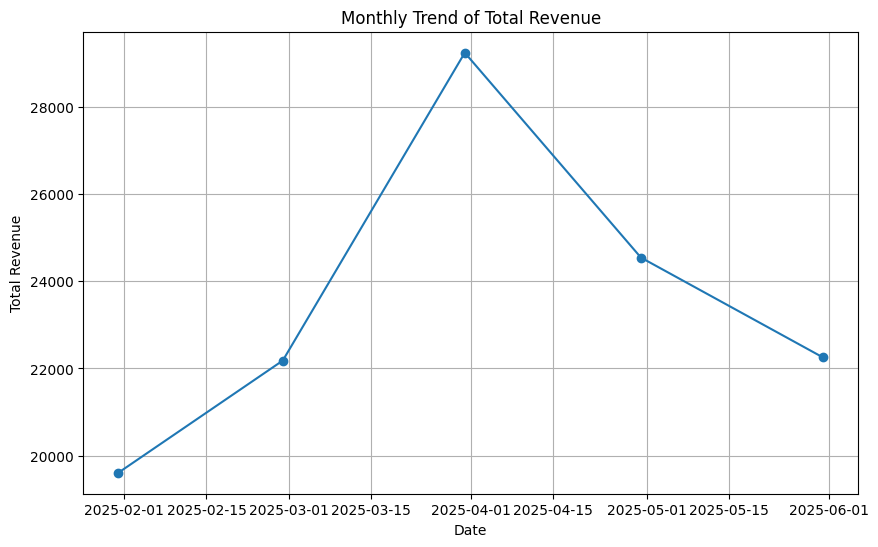

In [ ]:
if __name__ == "__main__":
    REAL_CSV_PATH = "ecommerce_sales.csv"
    import os
    
    import pandas as pd
    import io
    import sys
    import numpy as np
    print("🛠️ Generating clean, simulated data package...")
    np.random.seed(42)
    data = {
        'Order Date': pd.date_range(start='2025-01-01', periods=150, freq='D').strftime('%m/%d/%Y'),
        'Item Type': np.random.choice(['Electronics', 'Clothing', 'Home & Kitchen', 'Books', 'Beauty'], 150),
        'Total Revenue': np.random.uniform(50.0, 1500.0, 150).round(2)
    }
    df = pd.DataFrame(data)
    
    
    df['Total Revenue'] = df['Total Revenue'].astype(object)
    df.loc[15, 'Total Revenue'] = 'MISSING_DATA'
    df.loc[42, 'Total Revenue'] = 'UNKNOWN_VAL'
    df.to_csv(REAL_CSV_PATH, index=False)
    
    print("✅ 'ecommerce_sales.csv' generated safely.")

    
    real_df = pd.read_csv(REAL_CSV_PATH)
    schema_buffer = io.StringIO()
    real_df.info(buf=schema_buffer)
    dataset_schema = schema_buffer.getvalue()
    dataset_schema += f"\n\nFirst 3 rows sample:\n{real_df.head(3).to_string()}"

    
    analysis_query = (
        "Identify the top 5 performing 'Item Type' groups by summing up 'Total Revenue'. "
        "Be careful: 'Total Revenue' contains dirty text data like 'MISSING_DATA' and 'UNKNOWN_VAL'—"
        "you must coerce those string rows to numerical values or clear them out first! "
        "Once calculated, you MUST explicitly call print() to display the top 5 groups table in the terminal. "
        "Then, convert the 'Order Date' column to datetime format, and plot a clear line chart "
        "showing the monthly trend of 'Total Revenue'. Save the final visualization image as 'analysis_chart.png'."
    )

    
    initial_payload = {
        "query": analysis_query,
        "csv_path": REAL_CSV_PATH,
        "schema_info": dataset_schema,
        "error": "",
        "output": "",
        "iteration": 0
    }

    print("\n🚀 Launching Autonomous LangGraph Evaluation Cycle...")
    final_output_state = app.invoke(initial_payload)

   
    print("\n==============================================")
    print(" FINAL DATA ANALYST REPORT")
    print("==============================================")
    if final_output_state["output"]:
        print(final_output_state["output"])
    else:
        print("System evaluation stopped with unresolved anomalies:")
        print(final_output_state["error"])
        
    if os.path.exists("analysis_chart.png"):
        print("\n Success: Visualization generated and saved as 'analysis_chart.png'!")